 # Voxel Allegiance Analysis



 Explores three approaches to quantifying voxel-level category reorganization in VOTC:

 1. **Winner-take-all maps** — each voxel colored by its preferred category

 2. **Transition matrices** — which categories trade territory T1→T2

 3. **Profile stability** — cosine similarity of voxel response vectors across time



 Also computes Blauch-style summed selectivity per category per hemisphere.



 COPEs used:

 - Raw betas: face=15, house=16, object=17, word=18

 - Category vs all: face=6, house=7, object=8, word=9

 - Differential: face=1(>obj), house=2(>obj), object=3(>scr), word=4(>obj)

In [1]:
import os
import sys
import numpy as np
import nibabel as nib
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from scipy.spatial.distance import cosine
from scipy.stats import pearsonr
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, '/user_data/csimmon2/git_repos/sym_pt')
from sym_pt_params import (processed_dir, skip_subs, get_sessions,
                           is_patient, get_sub_info, _load_csv)


 ## Configuration

In [2]:
# ── Category definitions ──────────────────────────────────────────────────────

CATEGORIES = ['face', 'house', 'object', 'word']
CAT_COLORS = {
    'face':   '#E74C3C',   # red
    'house':  '#3498DB',   # blue
    'object': '#2ECC71',   # green
    'word':   '#F39C12',   # orange
    'none':   '#BDC3C7',   # gray (subthreshold)
}

# ── Cope maps ─────────────────────────────────────────────────────────────────
RAW_BETA_COPES = {'face': 15, 'house': 16, 'object': 17, 'word': 18}
CAT_VS_ALL_COPES = {'face': 6, 'house': 7, 'object': 8, 'word': 9}
DIFFERENTIAL_COPES = {'face': 1, 'house': 2, 'object': 3, 'word': 4}

# ── Which cope set to use for allegiance ──────────────────────────────────────
ALLEGIANCE_COPE_SET = 'raw_beta'   # <-- CHANGE THIS to try different approaches

# ── Thresholds ────────────────────────────────────────────────────────────────
WTA_THRESHOLD = 0

# ── Pre-surgery sessions to skip ──────────────────────────────────────────────
PRE_SURGERY_SESSIONS = {
    'sub-021': ['01'], 'sub-045': ['01'], 'sub-047': ['01'], 'sub-049': ['01'],
    'sub-070': ['01'], 'sub-073': ['01'], 'sub-081': ['01'], 'sub-086': ['01'],
}

# ── Exclusions ────────────────────────────────────────────────────────────────
EXCLUDE_SUBS = ['OTC108', 'control083', 'control085', 'OTC017']



 ## Helper Functions

In [3]:
def get_cope_map():
    """Return the cope mapping for the chosen allegiance set."""
    if ALLEGIANCE_COPE_SET == 'raw_beta':
        return RAW_BETA_COPES
    elif ALLEGIANCE_COPE_SET == 'cat_vs_all':
        return CAT_VS_ALL_COPES
    elif ALLEGIANCE_COPE_SET == 'differential':
        return DIFFERENTIAL_COPES
    else:
        raise ValueError(f"Unknown cope set: {ALLEGIANCE_COPE_SET}")


def load_subjects():
    """Load subject info, return dict keyed by sub ID."""
    df = _load_csv()
    subjects = {}
    for sub_clean in sorted(df['sub_clean'].unique()):
        if sub_clean in skip_subs:
            continue
        sid = f'sub-{sub_clean}'
        sessions = get_sessions(sub_clean)
        base = os.path.join(processed_dir, sid)
        if not sessions or not os.path.exists(base):
            continue
        info = get_sub_info(sub_clean, sessions[0])
        pt = is_patient(sub_clean)
        intact = info.get('intact_hemi', '')
        code = f"{info.get('group', '')}{sub_clean}"
        if code in EXCLUDE_SUBS:
            continue

        # Actual first session — always the true first (e.g. ses-01)
        # Used for ROI paths and cope filename suffixes
        actual_first_ses = f'{sessions[0]:02d}'

        # Filter sessions: remove pre-surgical for analysis
        post_sessions = []
        for s in sessions:
            ses_str = f'{s:02d}'
            if sid in PRE_SURGERY_SESSIONS and ses_str in PRE_SURGERY_SESSIONS[sid]:
                continue
            post_sessions.append(ses_str)

        if not post_sessions:
            continue

        subjects[sid] = {
            'code': code,
            'sessions': post_sessions,
            'actual_first_ses': actual_first_ses,
            'hemi': ('l' if intact == 'left' else 'r') if pt else None,
            'group': info.get('group', 'unknown'),
            'patient_status': 'patient' if pt else 'control',
            'intact_hemi': intact,
            'surgery_side': ('right' if intact == 'left' else 'left') if pt else 'na',
        }
    return subjects


def get_votc_mask(sub_id, actual_first_ses, hemi):
    """
    Get a broad VOTC mask by combining all 4 category searchmasks.
    Uses actual_first_ses (always ses-01) since searchmasks are anatomical.
    """
    roi_dir = os.path.join(processed_dir, sub_id, f'ses-{actual_first_ses}', 'ROIs')

    combined = None
    affine = None
    for cat in CATEGORIES:
        mask_path = os.path.join(roi_dir, f'{hemi}_{cat}_searchmask.nii.gz')
        if os.path.exists(mask_path):
            img = nib.load(mask_path)
            data = img.get_fdata() > 0
            if combined is None:
                combined = data.copy()
                affine = img.affine
            else:
                combined = combined | data

    if combined is None:
        ventral_dir = os.path.join(processed_dir, sub_id, f'ses-{actual_first_ses}',
                                    'derivatives', 'rois')
        ventral_path = os.path.join(ventral_dir, f'{hemi}Ventral.nii.gz')
        if os.path.exists(ventral_path):
            img = nib.load(ventral_path)
            combined = img.get_fdata() > 0
            affine = img.affine

    return combined, affine


def load_category_betas(sub_id, session, actual_first_ses, mask, cope_map):
    """
    Load beta/zstat values for all 4 categories within a mask.

    actual_first_ses: the true first session (e.g. '01'), used for
      cope filename suffix (cope1_ses01.nii.gz). Not filtered by pre-surgery.
    """
    feat_dir = os.path.join(processed_dir, sub_id, f'ses-{session}',
                            'derivatives', 'fsl', 'loc', 'HighLevel.gfeat')

    if ALLEGIANCE_COPE_SET == 'raw_beta':
        stat_file = 'cope1.nii.gz' if session == actual_first_ses else f'cope1_ses{actual_first_ses}.nii.gz'
    else:
        stat_file = 'zstat1.nii.gz' if session == actual_first_ses else f'zstat1_ses{actual_first_ses}.nii.gz'

    betas = {}
    for cat, cope_num in cope_map.items():
        fpath = os.path.join(feat_dir, f'cope{cope_num}.feat', 'stats', stat_file)
        if not os.path.exists(fpath):
            return None
        img = nib.load(fpath)
        data = img.get_fdata()
        betas[cat] = data[mask]

    return betas



 ## Load All Data

In [4]:
print("Loading subjects...")
subjects = load_subjects()
print(f"  {len(subjects)} subjects loaded")

# Check sub-017 excluded
print(f"  sub-017 in subjects? {'sub-017' in subjects}")

# Identify longitudinal subjects (2+ post-surgical sessions)
long_subs = {sid: info for sid, info in subjects.items()
             if len(info['sessions']) >= 2}
print(f"  {len(long_subs)} longitudinal subjects")

ctrl_long = {s: i for s, i in long_subs.items() if i['patient_status'] == 'control'}
pt_long = {s: i for s, i in long_subs.items() if i['patient_status'] == 'patient'}
print(f"    Controls: {len(ctrl_long)}, Patients: {len(pt_long)}")

# List patients with resection side
for s, i in pt_long.items():
    print(f"    {s}: surgery={i['surgery_side']}, intact={i['intact_hemi']}, "
          f"hemi={i['hemi']}, sessions={i['sessions']}, "
          f"actual_first={i['actual_first_ses']}")

# Cross-sectional
ctrl_all = {s: i for s, i in subjects.items() if i['patient_status'] == 'control'}
pt_all = {s: i for s, i in subjects.items() if i['patient_status'] == 'patient'}
print(f"  Cross-sectional — Controls: {len(ctrl_all)}, Patients: {len(pt_all)}")



Loading subjects...
  47 subjects loaded
  sub-017 in subjects? False
  17 longitudinal subjects
    Controls: 9, Patients: 8
    sub-004: surgery=right, intact=left, hemi=l, sessions=['01', '02', '03', '05', '06'], actual_first=01
    sub-007: surgery=left, intact=right, hemi=r, sessions=['01', '03', '04'], actual_first=01
    sub-008: surgery=right, intact=left, hemi=l, sessions=['01', '02'], actual_first=01
    sub-010: surgery=left, intact=right, hemi=r, sessions=['02', '03'], actual_first=02
    sub-021: surgery=left, intact=right, hemi=r, sessions=['02', '03'], actual_first=01
    sub-045: surgery=left, intact=right, hemi=r, sessions=['02', '03'], actual_first=01
    sub-072: surgery=right, intact=left, hemi=l, sessions=['01', '02'], actual_first=01
    sub-079: surgery=left, intact=right, hemi=r, sessions=['01', '02'], actual_first=01
  Cross-sectional — Controls: 22, Patients: 25


 ## 1. Winner-Take-All Maps

In [5]:
def compute_wta(betas, threshold=0):
    """
    Winner-take-all assignment for each voxel.
    Returns: winners (0-3 or -1), margin (1st-2nd), max_vals
    """
    n_voxels = len(betas[CATEGORIES[0]])
    beta_matrix = np.column_stack([betas[cat] for cat in CATEGORIES])

    max_vals = np.max(beta_matrix, axis=1)
    winners = np.argmax(beta_matrix, axis=1)

    sorted_betas = np.sort(beta_matrix, axis=1)
    margin = sorted_betas[:, -1] - sorted_betas[:, -2]

    if threshold > 0:
        winners[max_vals < threshold] = -1

    return winners, margin, max_vals


def wta_summary(winners):
    """Count voxels per category from WTA assignment."""
    total = len(winners)
    if total == 0:
        return {cat: 0 for cat in CATEGORIES + ['none']}, {cat: 0.0 for cat in CATEGORIES + ['none']}
    counts = {}
    for i, cat in enumerate(CATEGORIES):
        counts[cat] = int(np.sum(winners == i))
    counts['none'] = int(np.sum(winners == -1))
    pcts = {k: v / total * 100 for k, v in counts.items()}
    return counts, pcts



In [6]:
# ── Compute WTA for all subjects, first available session ─────────────────────

cope_map = get_cope_map()
threshold = WTA_THRESHOLD if ALLEGIANCE_COPE_SET == 'raw_beta' else 1.96

print(f"Cope set: {ALLEGIANCE_COPE_SET}")
print(f"Threshold: {threshold}")
print(f"Copes: {cope_map}")
print()

wta_results = {}
skipped = []

for sid, info in subjects.items():
    first_ses = info['sessions'][0]
    actual_first = info['actual_first_ses']
    hemi = info['hemi'] if info['patient_status'] == 'patient' else 'l'
    hemis = ['l', 'r'] if info['patient_status'] == 'control' else [hemi]

    for h in hemis:
        mask, affine = get_votc_mask(sid, actual_first, h)
        if mask is None:
            print(f"  SKIP {sid} {h}: no mask found")
            skipped.append((sid, h, 'no_mask'))
            continue

        n_mask_voxels = int(mask.sum())
        if n_mask_voxels == 0:
            print(f"  SKIP {sid} {h}: empty mask (0 voxels)")
            skipped.append((sid, h, 'empty_mask'))
            continue

        betas = load_category_betas(sid, first_ses, actual_first, mask, cope_map)
        if betas is None:
            print(f"  SKIP {sid} ses-{first_ses} {h}: cope files not found")
            skipped.append((sid, h, 'no_copes'))
            continue

        n_beta_voxels = len(betas[CATEGORIES[0]])
        if n_beta_voxels == 0:
            print(f"  SKIP {sid} {h}: betas empty after masking")
            skipped.append((sid, h, 'empty_betas'))
            continue

        winners, margin, max_vals = compute_wta(betas, threshold)
        counts, pcts = wta_summary(winners)

        wta_results[(sid, first_ses, h)] = {
            'winners': winners,
            'margin': margin,
            'max_vals': max_vals,
            'counts': counts,
            'pcts': pcts,
            'n_voxels': len(winners),
            'group': info['patient_status'],
            'surgery_side': info.get('surgery_side', 'na'),
            'info': info,
        }

print(f"\nComputed WTA for {len(wta_results)} subject-hemisphere entries")
print(f"Skipped {len(skipped)} entries:")
for sid, h, reason in skipped:
    print(f"  {sid} {h}: {reason}")



Cope set: raw_beta
Threshold: 0
Copes: {'face': 15, 'house': 16, 'object': 17, 'word': 18}

  SKIP sub-090 ses-01 r: cope files not found

Computed WTA for 68 subject-hemisphere entries
Skipped 1 entries:
  sub-090 r: no_copes


In [7]:
# ── Summarize WTA territory ──────────────────────────────────────────────────

def summarize_group_wta(wta_results, group, hemi=None, surgery_side=None):
    """Average WTA percentages across subjects in a group."""
    pct_rows = []
    for (sid, ses, h), res in wta_results.items():
        if res['group'] != group:
            continue
        if hemi is not None and h != hemi:
            continue
        if surgery_side is not None and res.get('surgery_side', 'na') != surgery_side:
            continue
        pct_rows.append(res['pcts'])

    if not pct_rows:
        return None
    df = pd.DataFrame(pct_rows)
    return df.describe()

print("=== CONTROLS — LEFT HEMISPHERE ===")
s = summarize_group_wta(wta_results, 'control', 'l')
if s is not None: print(s.loc[['count', 'mean', 'std']].round(1))

print("\n=== CONTROLS — RIGHT HEMISPHERE ===")
s = summarize_group_wta(wta_results, 'control', 'r')
if s is not None: print(s.loc[['count', 'mean', 'std']].round(1))

print("\n=== PATIENTS — L-RESECTION (intact LH) ===")
s = summarize_group_wta(wta_results, 'patient', 'l', surgery_side='right')
if s is not None: print(s.loc[['count', 'mean', 'std']].round(1))

print("\n=== PATIENTS — R-RESECTION (intact RH) ===")
s = summarize_group_wta(wta_results, 'patient', 'r', surgery_side='left')
if s is not None: print(s.loc[['count', 'mean', 'std']].round(1))



=== CONTROLS — LEFT HEMISPHERE ===
       face  house  object  word  none
count  22.0   22.0    22.0  22.0  22.0
mean   22.5   23.5    32.8  21.2   0.0
std    16.6    9.0    12.5   9.4   0.0

=== CONTROLS — RIGHT HEMISPHERE ===
       face  house  object  word  none
count  22.0   22.0    22.0  22.0  22.0
mean   26.2   27.5    28.4  17.9   0.0
std    16.2   10.4    12.6   8.7   0.0

=== PATIENTS — L-RESECTION (intact LH) ===
       face  house  object  word  none
count  13.0   13.0    13.0  13.0  13.0
mean   25.6   27.2    26.6  20.7   0.0
std    10.8    8.4     8.2  11.1   0.0

=== PATIENTS — R-RESECTION (intact RH) ===
       face  house  object  word  none
count  11.0   11.0    11.0  11.0  11.0
mean   29.6   24.6    27.9  17.9   0.0
std    11.6   10.4    10.9  10.7   0.0


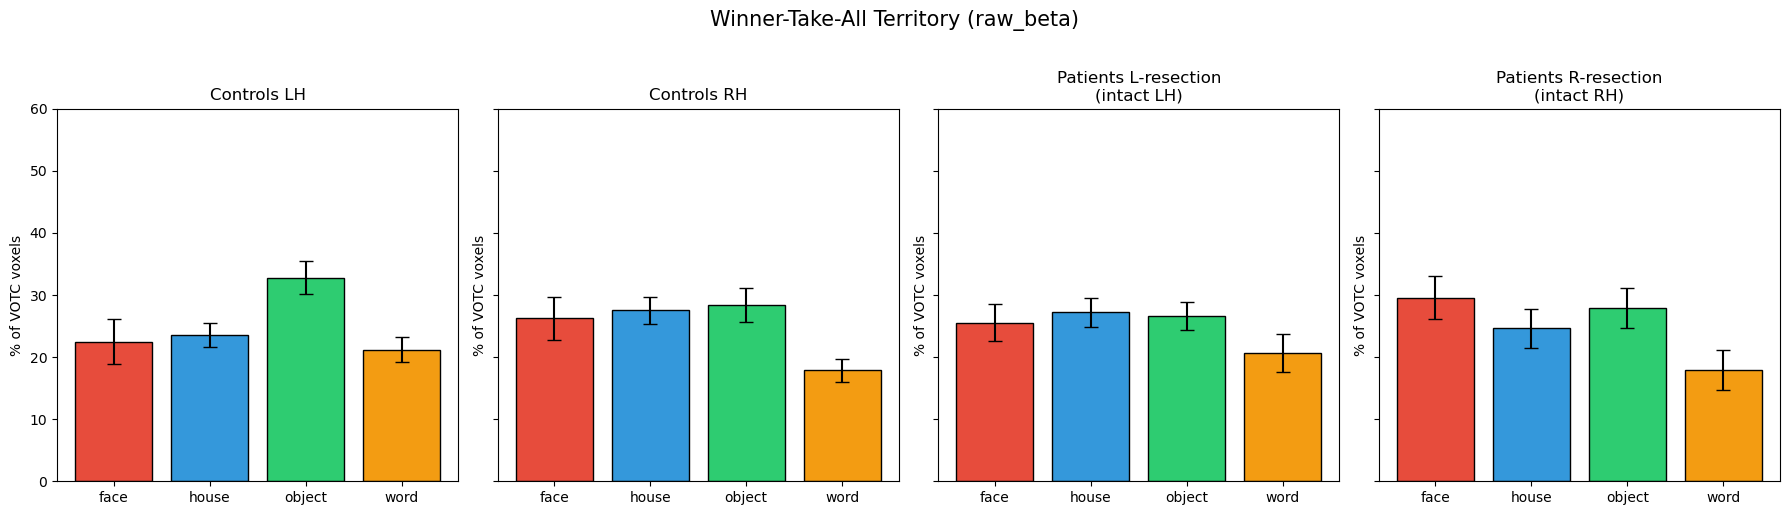

In [8]:
# ── Bar chart: Average territory per category ─────────────────────────────────

panels = [
    ('Controls LH', 'control', 'l', None),
    ('Controls RH', 'control', 'r', None),
    ('Patients L-resection\n(intact LH)', 'patient', 'l', 'right'),
    ('Patients R-resection\n(intact RH)', 'patient', 'r', 'left'),
]

fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=True)

for ax, (title, group, hemi, surg) in zip(axes, panels):
    pct_rows = []
    for (sid, ses, h), res in wta_results.items():
        if res['group'] != group:
            continue
        if hemi is not None and h != hemi:
            continue
        if surg is not None and res.get('surgery_side', 'na') != surg:
            continue
        pct_rows.append(res['pcts'])

    if not pct_rows:
        ax.set_title(f"{title}\n(no data)")
        continue

    df = pd.DataFrame(pct_rows)
    means = df[CATEGORIES].mean()
    sems = df[CATEGORIES].sem()

    bars = ax.bar(CATEGORIES, means, yerr=sems, capsize=5,
                  color=[CAT_COLORS[c] for c in CATEGORIES], edgecolor='black')
    ax.set_title(title, fontsize=12)
    ax.set_ylabel('% of VOTC voxels')
    ax.set_ylim(0, 60)

plt.suptitle(f'Winner-Take-All Territory ({ALLEGIANCE_COPE_SET})', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(processed_dir, 'group_results',
            f'wta_territory_{ALLEGIANCE_COPE_SET}.png'), dpi=150, bbox_inches='tight')
plt.show()



 ## 2. Longitudinal Transition Matrices

In [9]:
def compute_transition_matrix(winners_t1, winners_t2, n_categories=4):
    """
    Build transition matrix from T1 winners to T2 winners.
    Only includes voxels assigned to a category at BOTH timepoints.
    """
    valid = (winners_t1 >= 0) & (winners_t2 >= 0)
    w1 = winners_t1[valid]
    w2 = winners_t2[valid]

    trans = np.zeros((n_categories, n_categories), dtype=int)
    for i in range(len(w1)):
        trans[w1[i], w2[i]] += 1

    row_sums = trans.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    trans_pct = trans / row_sums * 100

    total_valid = valid.sum()
    retention = np.diag(trans).sum() / total_valid if total_valid > 0 else np.nan

    return trans, trans_pct, retention



In [10]:
# ── Compute transitions for longitudinal subjects ────────────────────────────

transition_results = {}

for sid, info in long_subs.items():
    sessions = info['sessions']
    t1_ses, t2_ses = sessions[0], sessions[-1]
    actual_first = info['actual_first_ses']

    hemi = info['hemi'] if info['patient_status'] == 'patient' else None
    hemis = [hemi] if hemi else ['l', 'r']

    for h in hemis:
        mask, affine = get_votc_mask(sid, actual_first, h)
        if mask is None:
            continue

        betas_t1 = load_category_betas(sid, t1_ses, actual_first, mask, cope_map)
        betas_t2 = load_category_betas(sid, t2_ses, actual_first, mask, cope_map)
        if betas_t1 is None or betas_t2 is None:
            continue

        winners_t1, margin_t1, _ = compute_wta(betas_t1, threshold)
        winners_t2, margin_t2, _ = compute_wta(betas_t2, threshold)

        trans, trans_pct, retention = compute_transition_matrix(winners_t1, winners_t2)

        transition_results[(sid, h)] = {
            'trans_counts': trans,
            'trans_pct': trans_pct,
            'retention': retention,
            'winners_t1': winners_t1,
            'winners_t2': winners_t2,
            'margin_t1': margin_t1,
            'margin_t2': margin_t2,
            'group': info['patient_status'],
            'surgery_side': info.get('surgery_side', 'na'),
            't1_ses': t1_ses,
            't2_ses': t2_ses,
            'info': info,
        }

print(f"Computed transitions for {len(transition_results)} subject-hemisphere entries")



Computed transitions for 26 subject-hemisphere entries


Controls LH: sub-018, sub-022, sub-025, sub-027, sub-052, sub-058, sub-062, sub-064, sub-068
Controls RH: sub-018, sub-022, sub-025, sub-027, sub-052, sub-058, sub-062, sub-064, sub-068
Patients L-resection
(intact LH): sub-004, sub-008, sub-072
Patients R-resection
(intact RH): sub-007, sub-010, sub-021, sub-045, sub-079


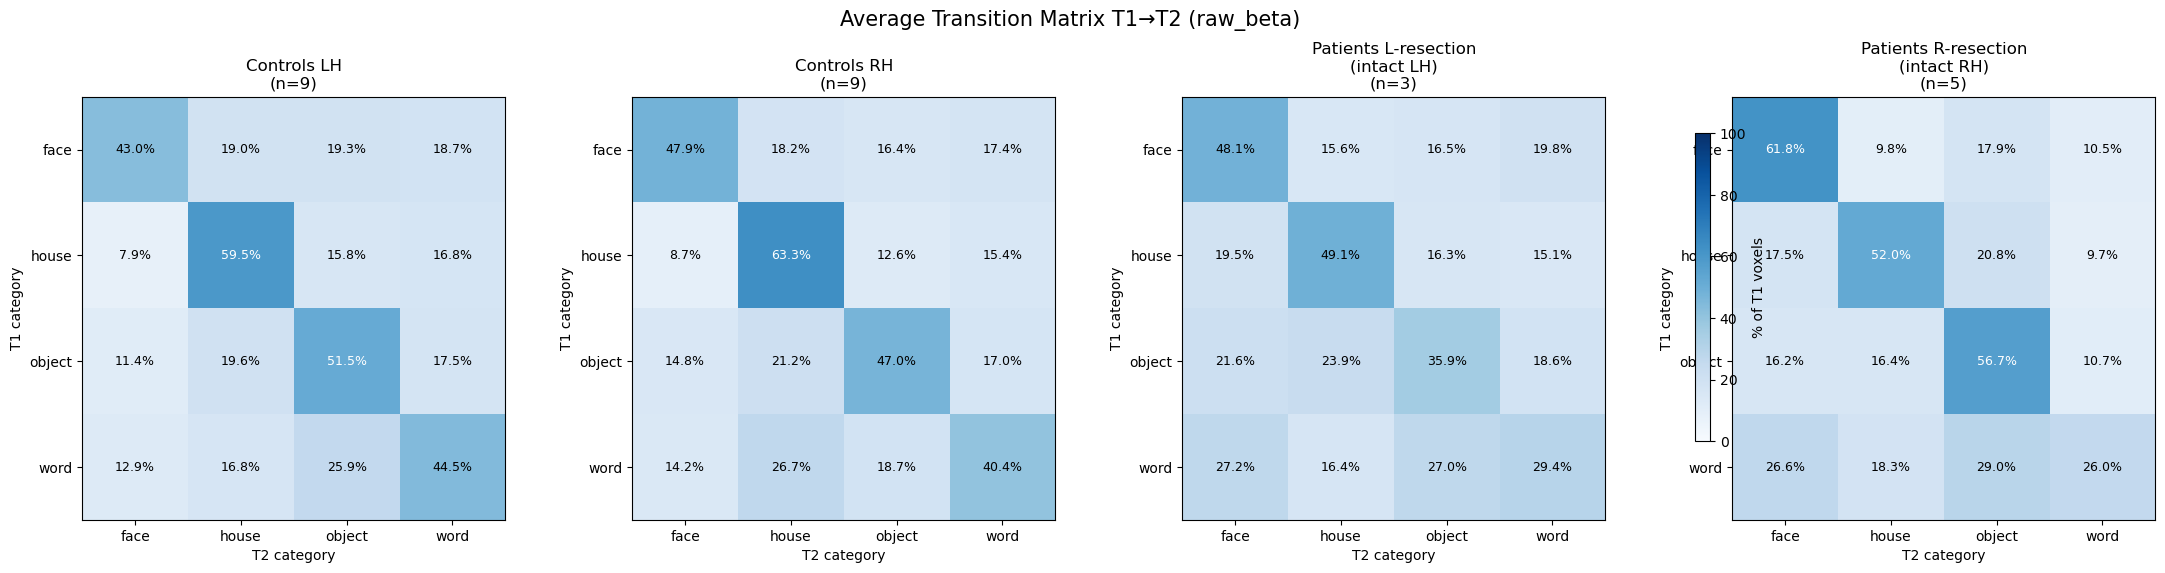

In [11]:
# ── Average transition matrix: split by group and resection side ──────────────

def avg_transition_matrix(results, group, hemi=None, surgery_side=None):
    """Average the percentage transition matrices across a group."""
    matrices = []
    sids = []
    for (sid, h), res in results.items():
        if res['group'] != group:
            continue
        if hemi is not None and h != hemi:
            continue
        if surgery_side is not None and res.get('surgery_side', 'na') != surgery_side:
            continue
        matrices.append(res['trans_pct'])
        sids.append(sid)

    if not matrices:
        return None, []
    return np.mean(matrices, axis=0), sids


panels = [
    ('Controls LH', 'control', 'l', None),
    ('Controls RH', 'control', 'r', None),
    ('Patients L-resection\n(intact LH)', 'patient', 'l', 'right'),
    ('Patients R-resection\n(intact RH)', 'patient', 'r', 'left'),
]

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for ax, (title, group, hemi, surg) in zip(axes, panels):
    avg_mat, sids = avg_transition_matrix(transition_results, group, hemi, surg)
    if avg_mat is None:
        ax.set_title(f"{title}\n(no data)")
        ax.axis('off')
        continue

    im = ax.imshow(avg_mat, cmap='Blues', vmin=0, vmax=100)
    ax.set_xticks(range(4))
    ax.set_yticks(range(4))
    ax.set_xticklabels(CATEGORIES, fontsize=10)
    ax.set_yticklabels(CATEGORIES, fontsize=10)
    ax.set_xlabel('T2 category')
    ax.set_ylabel('T1 category')
    ax.set_title(f'{title}\n(n={len(sids)})', fontsize=12)

    for i in range(4):
        for j in range(4):
            color = 'white' if avg_mat[i, j] > 50 else 'black'
            ax.text(j, i, f'{avg_mat[i, j]:.1f}%', ha='center', va='center',
                    fontsize=9, color=color)

    print(f"{title}: {', '.join(sids)}")

plt.colorbar(im, ax=axes, shrink=0.8, label='% of T1 voxels')
plt.suptitle(f'Average Transition Matrix T1→T2 ({ALLEGIANCE_COPE_SET})', fontsize=15, y=1.05)
plt.tight_layout()
plt.savefig(os.path.join(processed_dir, 'group_results',
            f'transition_matrix_split_{ALLEGIANCE_COPE_SET}.png'), dpi=150, bbox_inches='tight')
plt.show()



In [12]:
# ── Retention rates: split by resection side ─────────────────────────────────

retention_rows = []
for (sid, h), res in transition_results.items():
    for i, cat in enumerate(CATEGORIES):
        row_total = res['trans_counts'][i, :].sum()
        if row_total > 0:
            cat_retention = res['trans_counts'][i, i] / row_total
        else:
            cat_retention = np.nan
        retention_rows.append({
            'sub': sid,
            'hemi': h,
            'group': res['group'],
            'surgery_side': res.get('surgery_side', 'na'),
            'category': cat,
            'retention': cat_retention,
            'overall_retention': res['retention'],
        })

ret_df = pd.DataFrame(retention_rows)

print("=== RETENTION RATES (proportion voxels keeping same category T1→T2) ===\n")
print("Overall retention:")
print(ret_df.groupby(['group', 'surgery_side'])['overall_retention'].describe()[['mean', 'std', 'min', 'max']].round(3))

print("\nPer-category retention:")
pivot = ret_df.pivot_table(values='retention', index=['group', 'surgery_side'],
                           columns='category', aggfunc=['mean', 'std']).round(3)
print(pivot)



=== RETENTION RATES (proportion voxels keeping same category T1→T2) ===

Overall retention:
                       mean    std    min    max
group   surgery_side                            
control na            0.488  0.112  0.214  0.634
patient left          0.542  0.123  0.324  0.693
        right         0.417  0.089  0.333  0.533

Per-category retention:
                       mean                         std                     
category               face  house object   word   face  house object   word
group   surgery_side                                                        
control na            0.455  0.614  0.492  0.424  0.180  0.154  0.109  0.205
patient left          0.618  0.520  0.567  0.260  0.216  0.178  0.152  0.125
        right         0.481  0.491  0.359  0.294  0.236  0.195  0.200  0.131


 ## 3. Individual Patient Transition Matrices

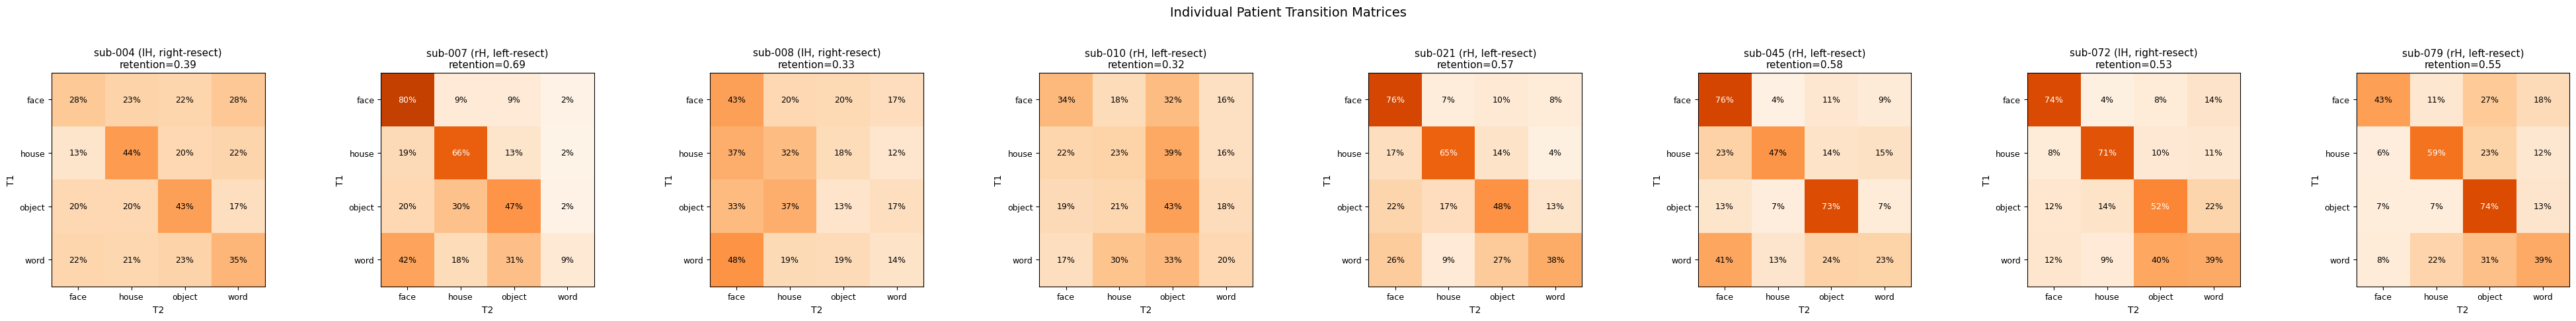

In [13]:
patient_trans = {k: v for k, v in transition_results.items() if v['group'] == 'patient'}

if patient_trans:
    n_patients = len(patient_trans)
    fig, axes = plt.subplots(1, n_patients, figsize=(5 * n_patients, 4.5))
    if n_patients == 1:
        axes = [axes]

    for ax, ((sid, h), res) in zip(axes, patient_trans.items()):
        im = ax.imshow(res['trans_pct'], cmap='Oranges', vmin=0, vmax=100)
        ax.set_xticks(range(4))
        ax.set_yticks(range(4))
        ax.set_xticklabels(CATEGORIES, fontsize=9)
        ax.set_yticklabels(CATEGORIES, fontsize=9)
        ax.set_xlabel('T2')
        ax.set_ylabel('T1')
        surgery = res.get('surgery_side', '?')
        ax.set_title(f'{sid} ({h}H, {surgery}-resect)\n'
                     f'retention={res["retention"]:.2f}', fontsize=11)

        for i in range(4):
            for j in range(4):
                color = 'white' if res['trans_pct'][i, j] > 50 else 'black'
                ax.text(j, i, f'{res["trans_pct"][i, j]:.0f}%',
                        ha='center', va='center', fontsize=9, color=color)

    plt.suptitle('Individual Patient Transition Matrices', fontsize=14, y=1.05)
    plt.tight_layout()
    plt.savefig(os.path.join(processed_dir, 'group_results',
                f'patient_transitions_{ALLEGIANCE_COPE_SET}.png'),
                dpi=150, bbox_inches='tight')
    plt.show()



 ## 4. Voxel Profile Stability

In [14]:
def compute_profile_stability(betas_t1, betas_t2):
    """
    For each voxel, compute cosine similarity of its 4-category response
    profile between T1 and T2.
    """
    mat_t1 = np.column_stack([betas_t1[cat] for cat in CATEGORIES])
    mat_t2 = np.column_stack([betas_t2[cat] for cat in CATEGORIES])

    dot_products = np.sum(mat_t1 * mat_t2, axis=1)
    norms_t1 = np.linalg.norm(mat_t1, axis=1)
    norms_t2 = np.linalg.norm(mat_t2, axis=1)

    denom = norms_t1 * norms_t2
    valid = denom > 0
    cos_sims = np.full(len(dot_products), np.nan)
    cos_sims[valid] = dot_products[valid] / denom[valid]

    return cos_sims, np.nanmean(cos_sims), np.nanmedian(cos_sims)



In [15]:
# ── Compute profile stability for longitudinal subjects ──────────────────────

stability_results = {}

for sid, info in long_subs.items():
    sessions = info['sessions']
    t1_ses, t2_ses = sessions[0], sessions[-1]
    actual_first = info['actual_first_ses']

    hemi = info['hemi'] if info['patient_status'] == 'patient' else None
    hemis = [hemi] if hemi else ['l', 'r']

    for h in hemis:
        mask, affine = get_votc_mask(sid, actual_first, h)
        if mask is None:
            continue

        betas_t1 = load_category_betas(sid, t1_ses, actual_first, mask, cope_map)
        betas_t2 = load_category_betas(sid, t2_ses, actual_first, mask, cope_map)
        if betas_t1 is None or betas_t2 is None:
            continue

        cos_sims, mean_cos, median_cos = compute_profile_stability(betas_t1, betas_t2)

        stability_results[(sid, h)] = {
            'cos_sims': cos_sims,
            'mean_cos': mean_cos,
            'median_cos': median_cos,
            'group': info['patient_status'],
            'surgery_side': info.get('surgery_side', 'na'),
            'info': info,
        }

print(f"Computed profile stability for {len(stability_results)} entries")



Computed profile stability for 26 entries


In [16]:
# ── Profile stability: Controls vs Patients ──────────────────────────────────

stab_rows = []
for (sid, h), res in stability_results.items():
    stab_rows.append({
        'sub': sid,
        'hemi': h,
        'group': res['group'],
        'surgery_side': res.get('surgery_side', 'na'),
        'mean_cos_sim': res['mean_cos'],
        'median_cos_sim': res['median_cos'],
    })

stab_df = pd.DataFrame(stab_rows)

print("=== PROFILE STABILITY (cosine similarity T1 vs T2) ===\n")
print(stab_df.groupby(['group', 'surgery_side'])[['mean_cos_sim', 'median_cos_sim']].describe().round(3))



=== PROFILE STABILITY (cosine similarity T1 vs T2) ===

                     mean_cos_sim                                            \
                            count   mean    std    min    25%    50%    75%   
group   surgery_side                                                          
control na                   18.0  0.611  0.117  0.403  0.526  0.590  0.737   
patient left                  5.0  0.564  0.236  0.148  0.596  0.668  0.697   
        right                 3.0  0.383  0.203  0.175  0.285  0.396  0.488   

                            median_cos_sim                                     \
                        max          count   mean    std    min    25%    50%   
group   surgery_side                                                            
control na            0.771           18.0  0.801  0.116  0.519  0.764  0.829   
patient left          0.710            5.0  0.746  0.291  0.228  0.847  0.853   
        right         0.580            3.0  0.550  0.296  0.243 

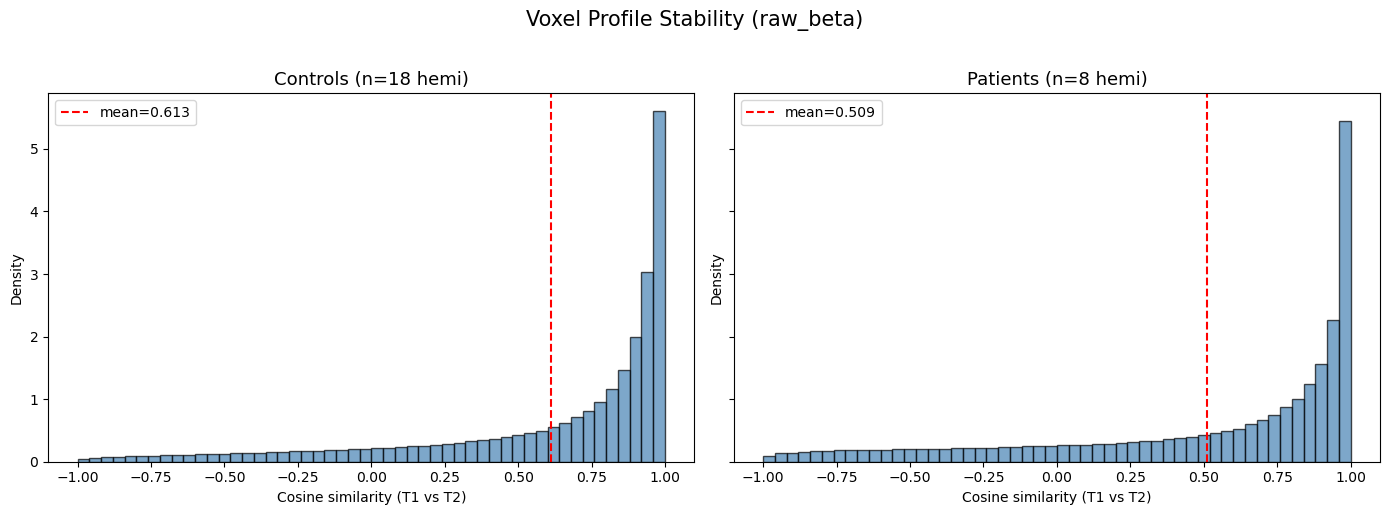

In [17]:
# ── Histogram of cosine similarities ─────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, (title, group) in zip(axes, [('Controls', 'control'), ('Patients', 'patient')]):
    all_cos = []
    for (sid, h), res in stability_results.items():
        if res['group'] != group:
            continue
        all_cos.append(res['cos_sims'])

    if not all_cos:
        ax.set_title(f"{title} (no data)")
        continue

    pooled = np.concatenate(all_cos)
    pooled = pooled[np.isfinite(pooled)]

    ax.hist(pooled, bins=50, range=(-1, 1), density=True, alpha=0.7,
            color='steelblue', edgecolor='black')
    ax.axvline(np.mean(pooled), color='red', linestyle='--', label=f'mean={np.mean(pooled):.3f}')
    ax.set_xlabel('Cosine similarity (T1 vs T2)')
    ax.set_ylabel('Density')
    ax.set_title(f'{title} (n={len(all_cos)} hemi)', fontsize=13)
    ax.legend()

plt.suptitle(f'Voxel Profile Stability ({ALLEGIANCE_COPE_SET})', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(processed_dir, 'group_results',
            f'profile_stability_{ALLEGIANCE_COPE_SET}.png'), dpi=150, bbox_inches='tight')
plt.show()



 ## 5. Blauch-Style Summed Selectivity

In [18]:
def compute_summed_selectivity(betas, mask_size):
    """
    Blauch (2025) style: for each category, sum positive values across all
    VOTC voxels. Captures both territory and magnitude.
    """
    result = {}
    for cat in CATEGORIES:
        vals = betas[cat]
        positive_vals = vals[vals > 0]
        result[cat] = {
            'summed_sel': float(np.sum(positive_vals)),
            'n_positive': int(len(positive_vals)),
            'pct_positive': float(len(positive_vals) / mask_size * 100) if mask_size > 0 else 0,
            'mean_positive': float(np.mean(positive_vals)) if len(positive_vals) > 0 else 0,
        }
    return result



In [19]:
# ── Compute summed selectivity: longitudinal subjects, all sessions ──────────
# Always uses cat_vs_all copes (6-9) regardless of ALLEGIANCE_COPE_SET

sumsel_cope_map = CAT_VS_ALL_COPES

sumsel_rows = []

for sid, info in long_subs.items():
    sessions = info['sessions']
    actual_first = info['actual_first_ses']
    hemi = info['hemi'] if info['patient_status'] == 'patient' else None
    hemis = [hemi] if hemi else ['l', 'r']

    for h in hemis:
        mask, affine = get_votc_mask(sid, actual_first, h)
        if mask is None:
            continue
        mask_size = int(mask.sum())

        for ses in sessions:
            betas = load_category_betas(sid, ses, actual_first, mask, sumsel_cope_map)
            if betas is None:
                continue

            ss = compute_summed_selectivity(betas, mask_size)

            for cat, vals in ss.items():
                sumsel_rows.append({
                    'sub': sid,
                    'ses': ses,
                    'hemi': h,
                    'group': info['patient_status'],
                    'surgery_side': info.get('surgery_side', 'na'),
                    'category': cat,
                    **vals,
                })

sumsel_df = pd.DataFrame(sumsel_rows)
if not sumsel_df.empty:
    print("=== SUMMED SELECTIVITY (cat_vs_all copes) ===\n")
    print("Longitudinal subjects, T1 vs T2:")

    for sid in sorted(long_subs.keys()):
        sub_df = sumsel_df[sumsel_df['sub'] == sid]
        if sub_df.empty:
            continue
        sessions = sorted(sub_df['ses'].unique())
        if len(sessions) < 2:
            continue

        group = long_subs[sid]['patient_status']
        surgery = long_subs[sid].get('surgery_side', 'na')
        hemis_used = sub_df['hemi'].unique()
        print(f"\n{sid} ({group}, {surgery}-resection, hemi={list(hemis_used)}):")
        for cat in CATEGORIES:
            t1_vals = sub_df[(sub_df['ses'] == sessions[0]) & (sub_df['category'] == cat)]['summed_sel']
            t2_vals = sub_df[(sub_df['ses'] == sessions[-1]) & (sub_df['category'] == cat)]['summed_sel']
            if t1_vals.empty or t2_vals.empty:
                print(f"  {cat:8s}: missing data")
                continue
            t1_val = t1_vals.iloc[0]
            t2_val = t2_vals.iloc[0]
            change = t2_val - t1_val
            print(f"  {cat:8s}: T1={t1_val:10.1f}  T2={t2_val:10.1f}  Δ={change:+10.1f}")



=== SUMMED SELECTIVITY (cat_vs_all copes) ===

Longitudinal subjects, T1 vs T2:

sub-004 (patient, right-resection, hemi=['l']):
  face    : T1=  240901.8  T2=  636979.3  Δ= +396077.6
  house   : T1= 1623014.3  T2= 1465692.4  Δ= -157321.9
  object  : T1= 1132796.9  T2= 1345549.6  Δ= +212752.7
  word    : T1=  153837.8  T2=  878587.9  Δ= +724750.1

sub-007 (patient, left-resection, hemi=['r']):
  face    : T1= 2053601.3  T2= 2586624.8  Δ= +533023.5
  house   : T1= 2084804.3  T2= 2582850.5  Δ= +498046.2
  object  : T1= 1168399.3  T2= 1906200.1  Δ= +737800.8
  word    : T1=  111697.3  T2=  270590.7  Δ= +158893.5

sub-008 (patient, right-resection, hemi=['l']):
  face    : T1=  923272.3  T2=  530505.8  Δ= -392766.5
  house   : T1=  847687.2  T2=  414405.9  Δ= -433281.3
  object  : T1=  652430.5  T2=  281375.7  Δ= -371054.8
  word    : T1=  196082.9  T2=  202018.4  Δ=   +5935.5

sub-010 (patient, left-resection, hemi=['r']):
  face    : T1=  802545.4  T2=  318059.8  Δ= -484485.6
  house   :

 ## 6. Margin Analysis

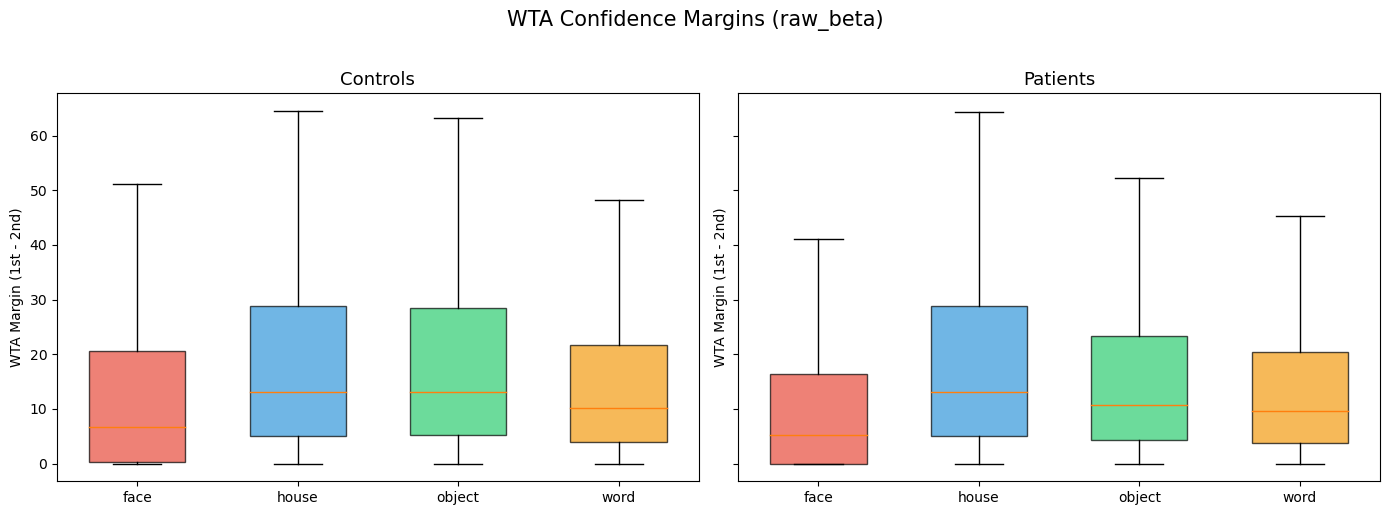

In [20]:
# ── Distribution of WTA margins: Controls vs Patients ────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, (title, group) in zip(axes, [('Controls', 'control'), ('Patients', 'patient')]):
    all_margins = {cat: [] for cat in CATEGORIES}

    for (sid, ses, h), res in wta_results.items():
        if res['group'] != group:
            continue
        for i, cat in enumerate(CATEGORIES):
            cat_mask = res['winners'] == i
            if cat_mask.sum() > 0:
                all_margins[cat].append(res['margin'][cat_mask])

    positions = []
    data = []
    colors = []
    for i, cat in enumerate(CATEGORIES):
        if all_margins[cat]:
            pooled = np.concatenate(all_margins[cat])
            data.append(pooled)
            positions.append(i)
            colors.append(CAT_COLORS[cat])

    if data:
        bp = ax.boxplot(data, positions=positions, widths=0.6, patch_artist=True,
                        showfliers=False)
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        ax.set_xticks(range(4))
        ax.set_xticklabels(CATEGORIES)

    ax.set_ylabel('WTA Margin (1st - 2nd)')
    ax.set_title(f'{title}', fontsize=13)

plt.suptitle(f'WTA Confidence Margins ({ALLEGIANCE_COPE_SET})', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(processed_dir, 'group_results',
            f'wta_margins_{ALLEGIANCE_COPE_SET}.png'), dpi=150, bbox_inches='tight')
plt.show()



 ## 7. Margin Change (Longitudinal)

In [21]:
margin_change_rows = []

for (sid, h), res in transition_results.items():
    for i, cat in enumerate(CATEGORIES):
        cat_at_t1 = res['winners_t1'] == i
        if cat_at_t1.sum() == 0:
            continue

        mean_margin_t1 = np.mean(res['margin_t1'][cat_at_t1])
        mean_margin_t2 = np.mean(res['margin_t2'][cat_at_t1])

        margin_change_rows.append({
            'sub': sid,
            'hemi': h,
            'group': res['group'],
            'surgery_side': res.get('surgery_side', 'na'),
            'category': cat,
            'mean_margin_t1': mean_margin_t1,
            'mean_margin_t2': mean_margin_t2,
            'margin_change': mean_margin_t2 - mean_margin_t1,
            'n_voxels': int(cat_at_t1.sum()),
        })

margin_df = pd.DataFrame(margin_change_rows)
if not margin_df.empty:
    print("=== MARGIN CHANGE T1→T2 ===")
    print("Positive = voxels became MORE committed, Negative = LESS committed\n")
    pivot = margin_df.pivot_table(values='margin_change',
                                   index=['group', 'surgery_side'],
                                   columns='category', aggfunc='mean').round(3)
    print(pivot)



=== MARGIN CHANGE T1→T2 ===
Positive = voxels became MORE committed, Negative = LESS committed

category               face  house  object   word
group   surgery_side                             
control na            0.628  6.210  -0.354  4.004
patient left          0.275 -3.175   0.643  2.231
        right         5.317 -3.536  -0.603 -1.665


 ## 8. Summary Table

In [22]:
summary_rows = []

for sid, info in long_subs.items():
    hemi = info['hemi'] if info['patient_status'] == 'patient' else None
    hemis = [hemi] if hemi else ['l', 'r']

    for h in hemis:
        row = {
            'sub': sid,
            'hemi': h,
            'group': info['patient_status'],
            'surgery_side': info.get('surgery_side', 'na'),
        }

        if (sid, h) in transition_results:
            row['overall_retention'] = transition_results[(sid, h)]['retention']
            for i, cat in enumerate(CATEGORIES):
                tc = transition_results[(sid, h)]['trans_counts']
                row_total = tc[i, :].sum()
                row[f'{cat}_retention'] = tc[i, i] / row_total if row_total > 0 else np.nan

        if (sid, h) in stability_results:
            row['mean_cos_sim'] = stability_results[(sid, h)]['mean_cos']
            row['median_cos_sim'] = stability_results[(sid, h)]['median_cos']

        summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
out_path = os.path.join(processed_dir, 'group_results',
                         f'voxel_allegiance_summary_{ALLEGIANCE_COPE_SET}.csv')
summary_df.to_csv(out_path, index=False)
print(f"Saved summary table: {out_path}")
print()
print(summary_df.to_string(index=False))



Saved summary table: /user_data/csimmon2/sym_pt/group_results/voxel_allegiance_summary_raw_beta.csv

    sub hemi   group surgery_side  overall_retention  face_retention  house_retention  object_retention  word_retention  mean_cos_sim  median_cos_sim
sub-004    l patient        right           0.385587        0.276304         0.444485          0.427607        0.346431      0.395810        0.574448
sub-007    r patient         left           0.692609        0.798210         0.663803          0.469669        0.094014      0.596031        0.847247
sub-008    l patient        right           0.332689        0.427410         0.323535          0.133647        0.144401      0.174833        0.242515
sub-010    r patient         left           0.324312        0.338633         0.233831          0.425924        0.204834      0.148195        0.228320
sub-018    l control           na           0.422600        0.200790         0.747324          0.323679        0.505912      0.537758        0.762311

 ## Notes on Interpretation



 **Cope set matters:**

 - `raw_beta`: Most neutral but noisy — all categories positive in most voxels

 - `cat_vs_all`: Best for allegiance — positive means this category wins

 - `differential`: face/house/word all vs object — not ideal for cross-category comparison



 **Run with all three and compare.** `cat_vs_all` is probably the most

 appropriate for allegiance claims. `raw_beta` is the most honest but noisiest.



 **The margin diagnostic:** If most voxels have tiny margins (Section 6),

 WTA is misleading. If margins are large, WTA is informative.



 **Connection to Blauch:** Summed selectivity (Section 5) is the

 territory-level version of the same question — how much total selectivity

 exists per category, without forcing each voxel to pick sides.

In [23]:
print("\n=== DONE ===")
print(f"Cope set used: {ALLEGIANCE_COPE_SET}")
print(f"All outputs saved to: {processed_dir}/group_results/")
print("\nTo run with a different cope set, change ALLEGIANCE_COPE_SET at the top")
print("Options: 'raw_beta', 'cat_vs_all', 'differential'")


=== DONE ===
Cope set used: raw_beta
All outputs saved to: /user_data/csimmon2/sym_pt/group_results/

To run with a different cope set, change ALLEGIANCE_COPE_SET at the top
Options: 'raw_beta', 'cat_vs_all', 'differential'
